In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv"
df_train = pd.read_csv(train_path)

# Fjern irrelevant features
irrelevant_cols = ["filnavn", "beta", "snr_db"]
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])

# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Klasse mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. FEATURE SCALING (VIGTIGT FOR SVM)
# ----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# ----------------------------
# 5. SVM MODEL
# ----------------------------
model = SVC(
    kernel="rbf",      # radial basis function kernel
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# 6. VALIDATION EVALUATION
# ----------------------------
y_val_pred = model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. TEST ON SEPARATE DATASET
# ----------------------------
test_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv"
df_test = pd.read_csv(test_path)

# fjern kun filnavn
if "filnavn" in df_test.columns:
    df_test = df_test.drop(columns=["filnavn"])

# behold beta og snr_db i df_test til senere analyse
X_test = df_test.drop(columns=["target", "beta", "snr_db"], errors="ignore")
y_test_true = label_encoder.transform(df_test["target"])

# skalér testdata (hvis du bruger SVM)
X_test = scaler.transform(X_test)

print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# ----------------------------
# 7. TEST PREDICTION
# ----------------------------
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5

Validation Accuracy: 0.9541062801932367

Classification Report (Validation):
              precision    recall  f1-score   support

   BlueNoise       0.93      0.97      0.95        69
  BrownNoise       0.93      0.91      0.92        69
       Clean       0.91      0.93      0.92        69
   PinkNoise       0.99      1.00      0.99        69
 VioletNoise       0.98      0.94      0.96        69
  WhiteNoise       0.99      0.97      0.98        69

    accuracy                           0.95       414
   macro avg       0.95      0.95      0.95       414
weighted avg       0.95      0.95      0.95       414


Confusion Matrix (Validation):
[[67  0  0  0  1  1]
 [ 0 63  6  0  0  0]
 [ 0  5 64  0  0  0]
 [ 0  0  0 69  0  0]
 [ 4  0  0  0 65  0]
 [ 1  0  0  1  0 67]]

Unikke targets i test: [0 1 2 3 4 5]
Antal prøver pr. klasse: [100 100 100 100 100 100]

Test Accuracy: 0.9666666

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54845/2593721819.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snr_error = df_noise.groupby("snr_bin")["correct"].mean()


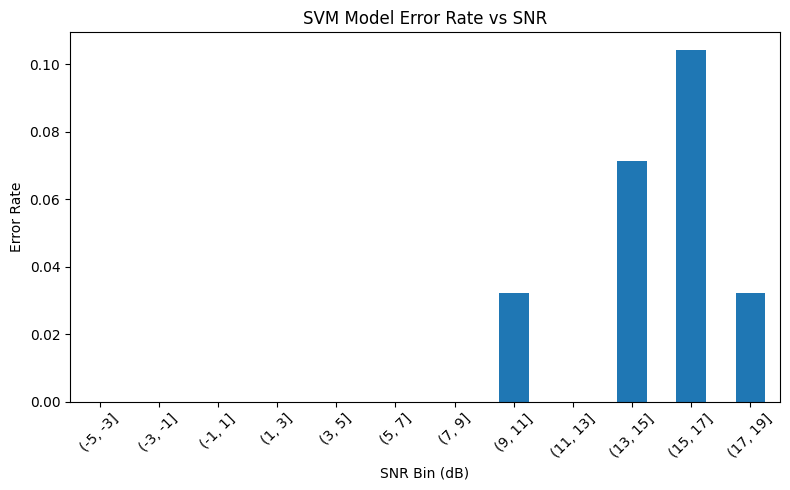

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54845/2593721819.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  beta_error = df_noise.groupby("beta_bin")["correct"].mean()


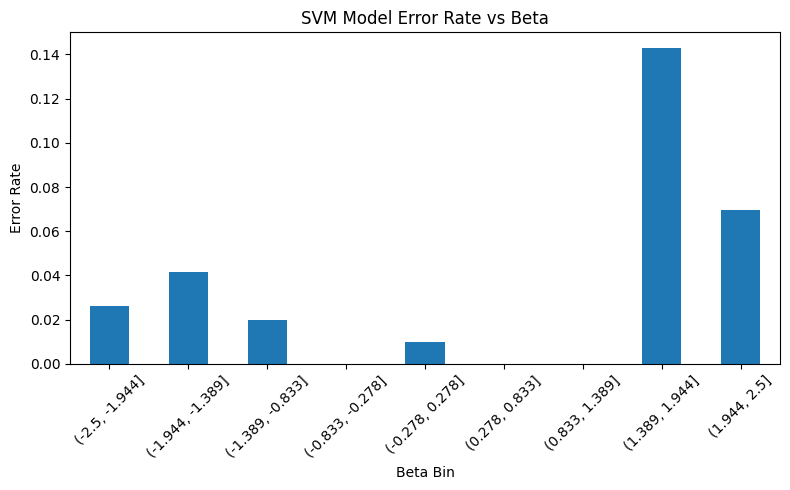


Test Accuracy: 0.9666666666666667

Classification Report (Test):
              precision    recall  f1-score   support

   BlueNoise       0.97      0.98      0.98       100
  BrownNoise       0.95      0.91      0.93       100
       Clean       0.90      0.95      0.93       100
   PinkNoise       1.00      1.00      1.00       100
 VioletNoise       0.99      0.97      0.98       100
  WhiteNoise       0.99      0.99      0.99       100

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600


Confusion Matrix (Test):
[[ 98   0   0   0   1   1]
 [  0  91   9   0   0   0]
 [  0   5  95   0   0   0]
 [  0   0   0 100   0   0]
 [  2   0   1   0  97   0]
 [  1   0   0   0   0  99]]

Eksempler på fejl:
      true_label   pred_label  beta  snr_db
48     BlueNoise   WhiteNoise -1.00   13.48
76     BlueNoise  VioletNoise -1.05   16.49
114   BrownNoise        Clean  1.93   14.01
115   

In [2]:
# ----------------------------
# 8. ERROR ANALYSIS (SNR & BETA)
# ----------------------------

# gem predictions i dataframe
df_analysis = df_test.copy()
df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

# behold kun støj (Clean har NaN)
df_noise = df_analysis.dropna(subset=["snr_db", "beta"]).copy()
# fejlrate pr SNR
snr_bins = np.arange(-5, 21, 2)
df_noise["snr_bin"] = pd.cut(df_noise["snr_db"], bins=snr_bins)

snr_error = df_noise.groupby("snr_bin")["correct"].mean()
snr_error = 1 - snr_error

plt.figure(figsize=(8,5))
snr_error.plot(kind="bar")
plt.title("SVM Model Error Rate vs SNR")
plt.ylabel("Error Rate")
plt.xlabel("SNR Bin (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# fejlrate pr beta
beta_bins = np.linspace(-2.5, 2.5, 10)
df_noise["beta_bin"] = pd.cut(df_noise["beta"], bins=beta_bins)

beta_error = df_noise.groupby("beta_bin")["correct"].mean()
beta_error = 1 - beta_error

plt.figure(figsize=(8,5))
beta_error.plot(kind="bar")
plt.title("SVM Model Error Rate vs Beta")
plt.ylabel("Error Rate")
plt.xlabel("Beta Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))


# ----------------------------
# ERROR ANALYSIS
# ----------------------------

df_analysis = df_test.copy()

df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

df_analysis["true_label"] = label_encoder.inverse_transform(df_analysis["y_true"])
df_analysis["pred_label"] = label_encoder.inverse_transform(df_analysis["y_pred"])

errors = df_analysis[df_analysis["correct"] == False]

print("\nEksempler på fejl:")
print(errors[["true_label","pred_label","beta","snr_db"]].head(20))

In [ ]:
# ----------------------------
# 9. 5-FOLD CROSS-VALIDATION PR. FEATURE (SVM) + GRID SEARCH + TEST PÅ ANDET DATASÆT
# Direkte boilerplate-struktur med grid-search i hvert fold
# ----------------------------
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD & PREPARE DATA
df_train_bp = pd.read_csv("https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv")

# Fjern irrelevante kolonner
irrelevant_cols = ["filnavn", "beta", "snr_db"]
for col in irrelevant_cols:
    if col in df_train_bp.columns:
        df_train_bp = df_train_bp.drop(columns=[col])

# 2. FEATURES & TARGET
X_bp = df_train_bp.drop(columns=["target"] )
y_bp = df_train_bp["target"]

# Encode labels
label_encoder_bp = LabelEncoder()
y_bp_encoded = label_encoder_bp.fit_transform(y_bp)

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1, 1]
}

results = []
for feature_name in X_bp.columns:
    X_single = X_bp[[feature_name]]

    # 3. TRAIN / VALIDATION SPLIT
    X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
        X_single, y_bp_encoded, test_size=0.20, stratify=y_bp_encoded, random_state=42
    )

    # 4. FEATURE SCALING (VIGTIGT FOR SVM)
    scaler_f = StandardScaler()
    X_train_f_s = scaler_f.fit_transform(X_train_f)
    X_val_f_s = scaler_f.transform(X_val_f)

    # 5. GRID SEARCH (på træningsfolden)
    grid = GridSearchCV(
        SVC(kernel="rbf", probability=True, random_state=42),
        param_grid,
        cv=5,
        n_jobs=-1,
        scoring='accuracy'
    )
    grid.fit(X_train_f_s, y_train_f)
    best_model = grid.best_estimator_

    # 5-fold cross-validation med bedste model
    cv_scores = cross_val_score(best_model, X_train_f_s, y_train_f, cv=5)

    # træning + validation accuracy (ekstra overblik)
    best_model.fit(X_train_f_s, y_train_f)
    val_acc = best_model.score(X_val_f_s, y_val_f)

    results.append(
        {
            "feature": feature_name,
            "cv_mean_accuracy": cv_scores.mean(),
            "cv_std": cv_scores.std(),
            "val_accuracy": val_acc,
            "best_params": grid.best_params_,
        }
    )

df_feature_cv = pd.DataFrame(results).sort_values(
    by="cv_mean_accuracy", ascending=False
).reset_index(drop=True)

print("SVM 5-fold accuracy pr. feature (med grid-search, boilerplate-metode):")
display(df_feature_cv)

best_row = df_feature_cv.iloc[0]
best_feature = best_row['feature']
print(
    f"\nBedste feature: {best_feature} | "
    f"CV mean: {best_row['cv_mean_accuracy']*100:.2f}% ± {best_row['cv_std']*100:.2f}% | "
    f"Val accuracy: {best_row['val_accuracy']*100:.2f}% | "
    f"Best params: {best_row['best_params']}"
 )

# ----------------------------
# TEST PÅ ANDET DATASÆT (ValidationData.csv)
# ----------------------------
df_test_bp = pd.read_csv("https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv")

if "filnavn" in df_test_bp.columns:
    df_test_bp = df_test_bp.drop(columns=["filnavn"])

X_test_bp = df_test_bp[[best_feature]]
y_test_bp = label_encoder_bp.transform(df_test_bp["target"])

# Skalér testdata med scaler fra træningsdata
scaler_best = StandardScaler()
X_train_best = X_bp[[best_feature]]
X_train_best_s = scaler_best.fit_transform(X_train_best)
X_test_best_s = scaler_best.transform(X_test_bp)

model_best = SVC(
    kernel="rbf",
    C=best_row['best_params']['C'],
    gamma=best_row['best_params']['gamma'],
    probability=True,
    random_state=42,
 )
model_best.fit(X_train_best_s, y_bp_encoded)
y_test_pred = model_best.predict(X_test_best_s)

print(f"\nTest på ValidationData.csv med bedste feature: {best_feature}")
print(f"Test Accuracy: {accuracy_score(y_test_bp, y_test_pred):.3f}")
print("\nClassification Report (Test):")
print(classification_report(y_test_bp, y_test_pred, target_names=label_encoder_bp.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_bp, y_test_pred))

SVM 5-fold accuracy pr. feature (boilerplate-metode):


,feature,cv_mean_accuracy,cv_std,val_accuracy
0,flatness_std,0.718003,0.014206,0.722222
1,flatness_mean,0.621390,0.025465,0.640097
2,centroid_mean,0.547703,0.005350,0.543478
3,rolloff_mean,0.530179,0.020937,0.545894
4,zcr_mean,0.509063,0.012674,0.483092
5,mfcc2_mean,0.496973,0.015101,0.500000
6,zcr_std,0.483078,0.042599,0.509662
7,bandwidth_std,0.480668,0.014315,0.483092
8,flux_std,0.458916,0.023493,0.458937
9,mfcc1_std,0.448054,0.024403,0.446860



Bedste feature: flatness_std | CV mean: 71.80% ± 1.42% | Val accuracy: 72.22%

Test på ValidationData.csv med bedste feature: flatness_std
Test Accuracy: 0.725

Classification Report (Test):
              precision    recall  f1-score   support

   BlueNoise       0.65      0.82      0.73       100
  BrownNoise       0.88      0.94      0.91       100
       Clean       0.62      0.29      0.39       100
   PinkNoise       0.61      0.85      0.71       100
 VioletNoise       0.79      0.86      0.82       100
  WhiteNoise       0.83      0.59      0.69       100

    accuracy                           0.72       600
   macro avg       0.73      0.72      0.71       600
weighted avg       0.73      0.72      0.71       600


Confusion Matrix (Test):
[[82  0  0  0 10  8]
 [ 0 94  6  0  0  0]
 [ 2 13 29 49  3  4]
 [ 0  0 12 85  3  0]
 [ 8  0  0  6 86  0]
 [34  0  0  0  7 59]]
